In [2]:
import sys

# Delete the cached module
if 'VaR - domrf' in sys.modules:
    del sys.modules['VaR - domrf']

# Re-import with __import__()
megavar = __import__('VaR - domrf')

import pandas as pd
import jax.numpy as jnp
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel('hist.xlsx')
print(df.head())

usd_price = df['USD'].to_numpy()
eur_price = df['EUR'].to_numpy()
cny_price = df['CNY'].to_numpy()

        date      USD      EUR      CNY
0 2019-01-10  67.0795  76.9066  98.1498
1 2019-01-11  66.8605  77.2105  98.6216
2 2019-01-12  66.9167  77.1282  99.1491
3 2019-01-15  67.1920  77.0692  99.4318
4 2019-01-16  67.0820  76.9498  99.3292


In [4]:
#yuan handling 
mask = cny_price > 60 
cny_price[mask] = cny_price[mask]/10 #ensuring cohesion
cny_price

array([ 9.81498,  9.86216,  9.91491, ..., 11.4165 , 11.5581 , 11.3685 ],
      shape=(1667,))

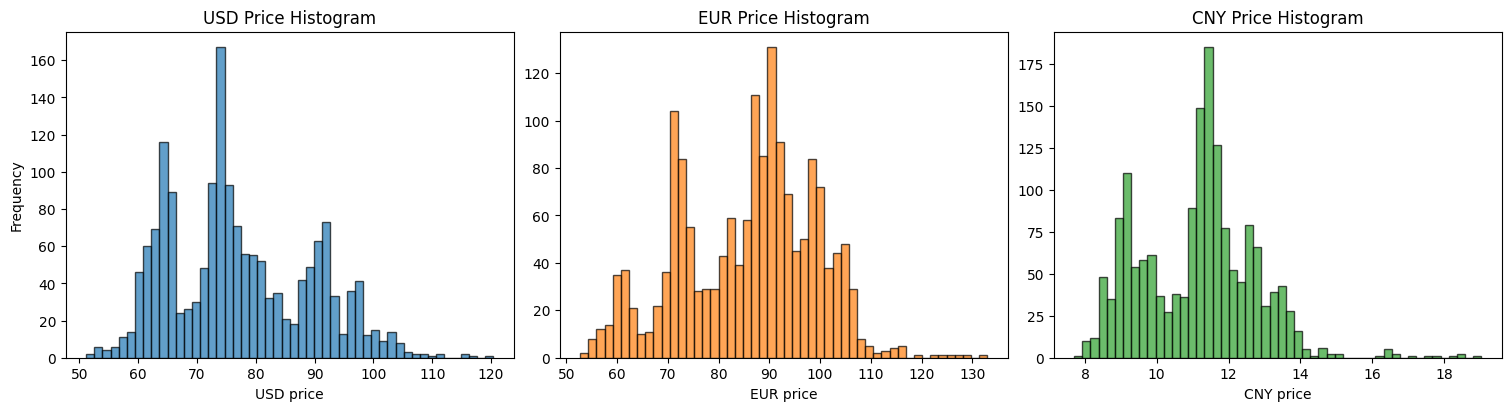

In [5]:
# plot histograms for the three price arrays already present in the notebook
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].hist(usd_price, bins=50, color='tab:blue', edgecolor='k', alpha=0.7)
axes[0].set_title('USD Price Histogram')
axes[0].set_xlabel('USD price')
axes[0].set_ylabel('Frequency')

axes[1].hist(eur_price, bins=50, color='tab:orange', edgecolor='k', alpha=0.7)
axes[1].set_title('EUR Price Histogram')
axes[1].set_xlabel('EUR price')

axes[2].hist(cny_price, bins=50, color='tab:green', edgecolor='k', alpha=0.7)
axes[2].set_title('CNY Price Histogram')
axes[2].set_xlabel('CNY price')

plt.show()

In [6]:
def return_array(prices): 
    rets = np.diff(prices) / prices[:-1]
    rets = jnp.array(rets, dtype='float64')
    return rets 

In [7]:
cny_rets = return_array(cny_price)
usd_rets = return_array(usd_price)
eur_rets = return_array(eur_price)

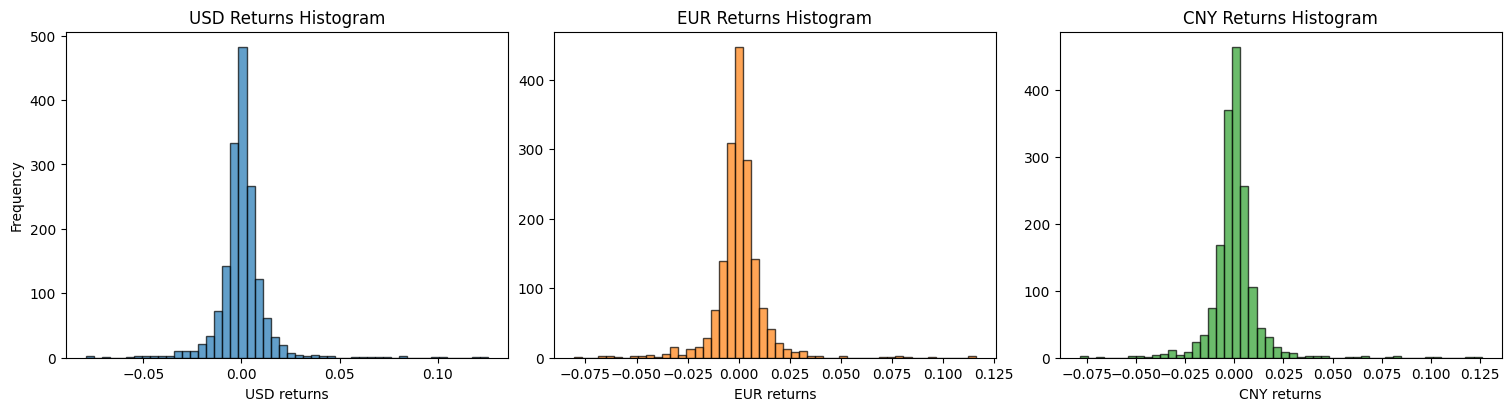

In [8]:
# plot histograms for the three price arrays already present in the notebook
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].hist(usd_rets, bins=50, color='tab:blue', edgecolor='k', alpha=0.7)
axes[0].set_title('USD Returns Histogram')
axes[0].set_xlabel('USD returns')
axes[0].set_ylabel('Frequency')

axes[1].hist(eur_rets, bins=50, color='tab:orange', edgecolor='k', alpha=0.7)
axes[1].set_title('EUR Returns Histogram')
axes[1].set_xlabel('EUR returns')

axes[2].hist(cny_rets, bins=50, color='tab:green', edgecolor='k', alpha=0.7)
axes[2].set_title('CNY Returns Histogram')
axes[2].set_xlabel('CNY returns')

plt.show()

In [9]:
alpha = 0.01
megavar.Test.var_all_methods(cny_rets, alpha, u=.9)

historical_var() took 0.164332s
Historical VaR: 0.03430672012839299
parametric_var_normal() took 0.098829s
Parametric VaR: 0.02852713585555889
garch_var() took 0.023103s
GARCH(1,1) with Normal distribution VaR: 0.025657026267490113
garch_var() took 0.008384s
GARCH(1,1) with Student distribution VaR: 0.03411462528257083
GPD_ppf() took 0.005126s
MLE_EVT() took 1.341004s
IMPORTANT 166 1666 0.03660149746661459 0.0004403743740152379 5
EVT VaR 0.09349706330074223


In [10]:
megavar.Test.var_all_methods(usd_rets, alpha, u=.95)

historical_var() took 0.000177s
Historical VaR: 0.03268264690152301
parametric_var_normal() took 0.000597s
Parametric VaR: 0.028770317451891556
garch_var() took 0.013277s
GARCH(1,1) with Normal distribution VaR: 0.02519275402969398
garch_var() took 0.014749s
GARCH(1,1) with Student distribution VaR: 0.03311191147299352
GPD_ppf() took 0.005079s
MLE_EVT() took 0.693462s
IMPORTANT 83 1666 0.03669500070791336 -0.022614352415433688 5
!!!!!!!!!!FLAG
EVT VaR 0.07299237084563931


In [11]:
megavar.Test.var_all_methods(eur_rets, alpha, u=.925)

historical_var() took 0.000124s
Historical VaR: 0.03661629868244053
parametric_var_normal() took 0.000578s
Parametric VaR: 0.02943693137268712
garch_var() took 0.009455s
GARCH(1,1) with Normal distribution VaR: 0.020847540213492832
garch_var() took 0.008854s
GARCH(1,1) with Student distribution VaR: 0.027051897078091195
GPD_ppf() took 0.002430s
MLE_EVT() took 0.569003s
IMPORTANT 124 1666 0.036681035930805045 -0.019461026921286262 5
!!!!!!!!!!FLAG
EVT VaR 0.08421217404033615


EVT suggests that the data follows normal disitribution, yet historical, parametric and GARCH(1,1) discrepancies do not support that claim

In [ ]:
#Generated using VS copilot
from scipy import stats

def test_normality(name, data, alpha=alpha):
    x = np.asarray(data).ravel()
    x = x[~np.isnan(x)]
    n = x.size
    print(f"Normality tests for {name} (n={n}):")

    # Shapiro-Wilk
    try:
        stat, p = stats.shapiro(x)
        print(f" Shapiro-Wilk: stat={stat:.4f}, p={p:.4g} -> {'reject' if p < alpha else 'fail to reject'} H0 (alpha={alpha})")
    except Exception as e:
        print(f" Shapiro-Wilk: failed ({e})")

    # D'Agostino-Pearson (normaltest)
    stat, p = stats.normaltest(x)
    print(f" D'Agostino-Pearson: stat={stat:.4f}, p={p:.4g} -> {'reject' if p < alpha else 'fail to reject'} H0")

    # Jarque-Bera
    stat, p = stats.jarque_bera(x)
    print(f" Jarque-Bera: stat={stat:.4f}, p={p:.4g} -> {'reject' if p < alpha else 'fail to reject'} H0")

    # Anderson-Darling
    res = stats.anderson(x, dist='norm')
    # Try to find the critical value matching alpha (significance levels provided in percent)
    target_pct = alpha * 100
    idxs = np.where(np.isclose(res.significance_level, target_pct))[0]
    if idxs.size:
        cv = res.critical_values[idxs[0]]
        verdict = 'reject' if res.statistic > cv else 'fail to reject'
        print(f" Anderson-Darling: stat={res.statistic:.4f}, critical({int(target_pct)}%)={cv:.4f} -> {verdict} H0")
    else:
        # show all critical values and give conservative interpretation vs 1% level
        print(f" Anderson-Darling: stat={res.statistic:.4f}, critical_values={list(zip(res.significance_level, res.critical_values))}")
        cv_1pct = res.critical_values[-1]  # typically the most stringent (1%)
        verdict = 'reject' if res.statistic > cv_1pct else 'fail to reject'
        print(f"  Interpretation vs 1% level: stat>{cv_1pct:.4f} -> {verdict} H0")

    print("-" * 60)

for name, arr in [('USD', usd_rets), ('EUR', eur_rets), ('CNY', cny_rets)]:
    test_normality(name, arr, alpha)

Normality tests for USD (n=1666):
 Shapiro-Wilk: stat=0.7635, p=9.498e-44 -> reject H0 (alpha=0.01)
 D'Agostino-Pearson: stat=908.6379, p=4.918e-198 -> reject H0
 Jarque-Bera: stat=38997.5624, p=0 -> reject H0
 Anderson-Darling: stat=79.3543, critical(1%)=1.0890 -> reject H0
------------------------------------------------------------
Normality tests for EUR (n=1666):
 Shapiro-Wilk: stat=0.7732, p=4.134e-43 -> reject H0 (alpha=0.01)
 D'Agostino-Pearson: stat=763.0784, p=1.994e-166 -> reject H0
 Jarque-Bera: stat=29230.4120, p=0 -> reject H0
 Anderson-Darling: stat=79.9199, critical(1%)=1.0890 -> reject H0
------------------------------------------------------------
Normality tests for CNY (n=1666):
 Shapiro-Wilk: stat=0.7468, p=8.532e-45 -> reject H0 (alpha=0.01)
 D'Agostino-Pearson: stat=932.6512, p=3.002e-203 -> reject H0
 Jarque-Bera: stat=43422.5007, p=0 -> reject H0
 Anderson-Darling: stat=88.2967, critical(1%)=1.0890 -> reject H0
--------------------------------------------------

Student-t (df=2) QQ for USD (n=1666):


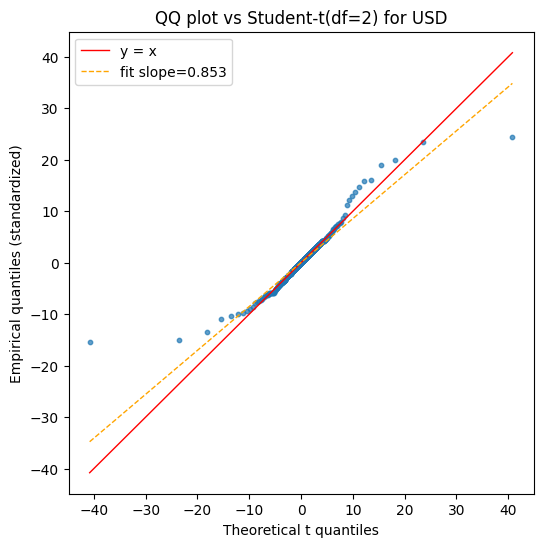

  Fit slope=0.8532, intercept=0.0342
------------------------------------------------------------
Student-t (df=2) QQ for EUR (n=1666):


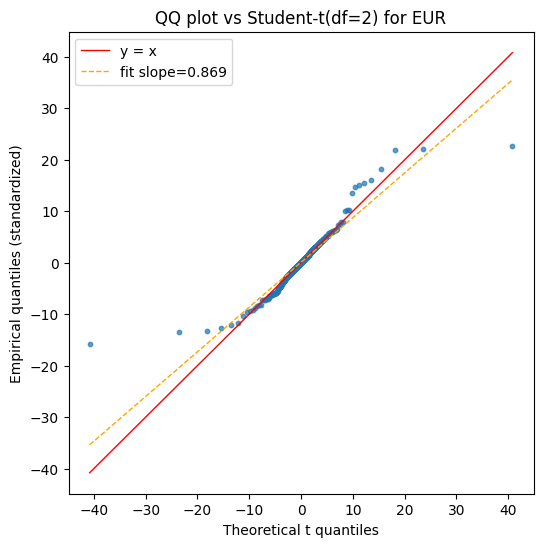

  Fit slope=0.8689, intercept=0.0700
------------------------------------------------------------
Student-t (df=2) QQ for CNY (n=1666):


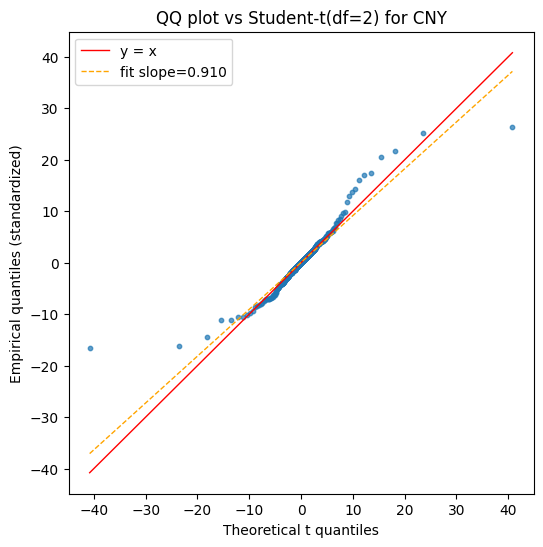

  Fit slope=0.9100, intercept=0.0467
------------------------------------------------------------


In [ ]:
#Generated using VS copilot
# Test for Student's t distribution (no parameter fitting: use robust standardization)

def test_student_t(name, data, df=2, alpha=alpha, n_boot=0, random_state=0):
    x = np.asarray(data).ravel()
    x = x[~np.isnan(x)]
    n = x.size
    print(f"Student-t (df={df}) QQ for {name} (n={n}):")

    # Robust location/scale using median and IQR mapped to theoretical t-IQR (no fitting)
    med_emp = np.median(x)
    emp_q75, emp_q25 = np.percentile(x, [75, 25])
    th_q75, th_q25 = stats.t.ppf([0.75, 0.25], df)
    denom = (th_q75 - th_q25)
    if denom == 0:
        scale = np.std(x) if np.std(x) > 0 else 1.0
    else:
        scale = (emp_q75 - emp_q25) / denom
        if scale == 0:
            scale = np.std(x) if np.std(x) > 0 else 1.0

    # Standardize data using robust loc/scale (this is NOT fitting distribution parameters)
    z = (x - med_emp) / scale

    # QQ plot: theoretical t quantiles vs empirical quantiles of standardized data
    z_sorted = np.sort(z)
    probs = (np.arange(1, n + 1) - 0.5) / n
    th_q = stats.t.ppf(probs, df)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(th_q, z_sorted, s=10, alpha=0.7)
    # identity line
    xmin, xmax = np.nanmin(th_q), np.nanmax(th_q)
    ax.plot([xmin, xmax], [xmin, xmax], color='r', lw=1, label='y = x')
    # fitted line for guidance
    m, b = np.polyfit(th_q, z_sorted, 1)
    ax.plot([xmin, xmax], [m * xmin + b, m * xmax + b], color='orange', lw=1, ls='--', label=f'fit slope={m:.3f}')
    ax.set_xlabel('Theoretical t quantiles')
    ax.set_ylabel('Empirical quantiles (standardized)')
    ax.set_title(f'QQ plot vs Student-t(df={df}) for {name}')
    ax.legend()
    plt.show()

    print(f"  Fit slope={m:.4f}, intercept={b:.4f}")
    print("-" * 60)

for name, arr in [('USD', usd_rets), ('EUR', eur_rets), ('CNY', cny_rets)]:
    test_student_t(name, arr, df=2, alpha=alpha)


0.0
